# Advanced Lung Cancer Detection using Deep Learning
### Multi-Class Classification (Benign, Malignant, Normal)

In [3]:
# Import libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [4]:
# Load dataset (3 classes)

data_dir = "../Data_3class"

categories = ["benign", "malignant", "normal"]

img_size = 128

X = []
y = []

for category in categories:

    folder_path = os.path.join(data_dir, category)
    label = categories.index(category)

    for file_name in os.listdir(folder_path):

        file_path = os.path.join(folder_path, file_name)

        try:
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (img_size, img_size))

            X.append(img)
            y.append(label)

        except:
            pass


X = np.array(X)
y = np.array(y)

X = X.reshape(-1, img_size, img_size, 1)
X = X / 255.0

y = to_categorical(y, num_classes=3)

print("Total images:", len(X))
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Total images: 1097
Shape of X: (1097, 128, 128, 1)
Shape of y: (1097, 3)


In [5]:
# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 877
Testing samples: 220


In [6]:
# Build a Multi-Class CNN Model
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(128, 128, 1)))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,451 (12.61 MB)

 Trainable params: 3,304,451 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.5519 - loss: 0.9376 - val_accuracy: 0.6682 - val_loss: 0.7933
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.6887 - loss: 0.7444 - val_accuracy: 0.7136 - val_loss: 0.6309
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7777 - loss: 0.5518 - val_accuracy: 0.7955 - val_loss: 0.4563
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.8506 - loss: 0.3755 - val_accuracy: 0.8773 - val_loss: 0.3415
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8928 - loss: 0.2783 - val_accuracy: 0.8591 - val_loss: 0.2750
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.9304 - loss: 0.1966 - val_accuracy: 0.9591 - val_loss: 0.1447
Epoch 7/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.9498 - loss: 0.1290 - val_accuracy: 0.9773 - val_loss: 0.0973
Epoch 8/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9647 - loss: 0.1031 - val_accuracy: 0.9818 - 

In [8]:
# Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9864 - loss: 0.0334
Test Loss: 0.03339216858148575
Test Accuracy: 0.9863636493682861


In [9]:
# Generate Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant", "Normal"]))
print(confusion_matrix(y_true, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        24
   Malignant       1.00      0.99      1.00       113
      Normal       0.98      0.99      0.98        83

    accuracy                           0.99       220
   macro avg       0.98      0.98      0.98       220
weighted avg       0.99      0.99      0.99       220

[[ 23   0   1]
 [  0 112   1]
 [  1   0  82]]


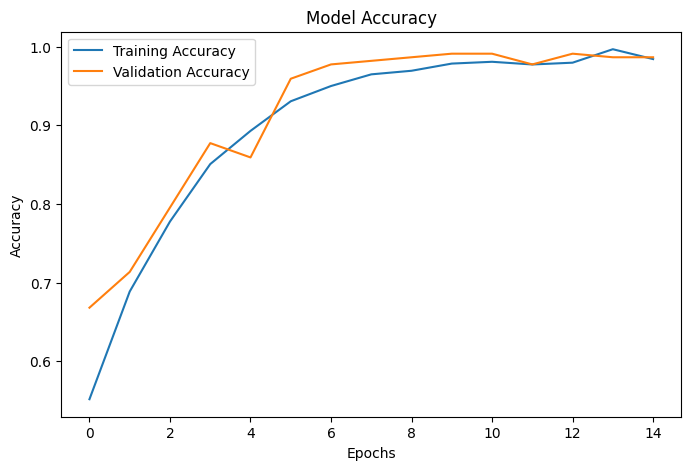

In [22]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.savefig("training_model_accuracy.png")
plt.show()

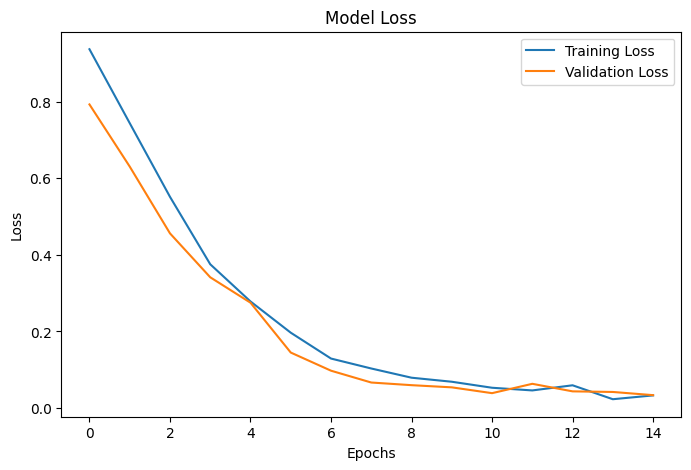

In [13]:
# Plot Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.savefig("training_loss.png")
plt.show()

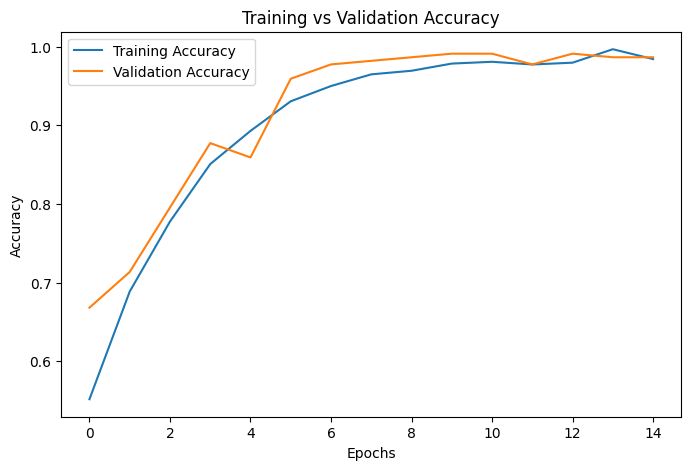

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig("training_accuracy.png")
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


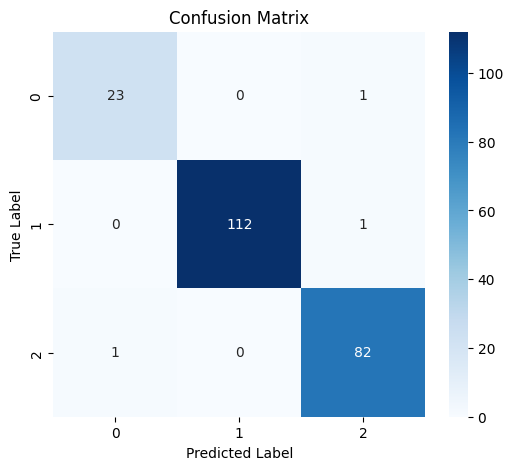

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("confusion_matrix.png")
plt.show()

In [16]:
# Save the Trained Model
model.save("../models/advanced_lung_cancer_model.keras")

In [17]:
from tensorflow.keras.models import load_model

model = load_model("../models/advanced_lung_cancer_model.keras")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,913,355 (37.82 MB)

 Trainable params: 3,304,451 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,904 (25.21 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


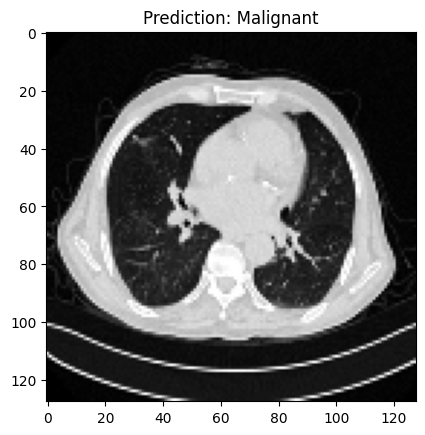

In [18]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["Benign","Malignant","Normal"]

index = 10

plt.imshow(X_test[index].reshape(128,128), cmap="gray")

prediction = model.predict(X_test[index].reshape(1,128,128,1))
predicted_class = classes[np.argmax(prediction)]

plt.title("Prediction: " + predicted_class)
plt.savefig("prediction_malignant.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


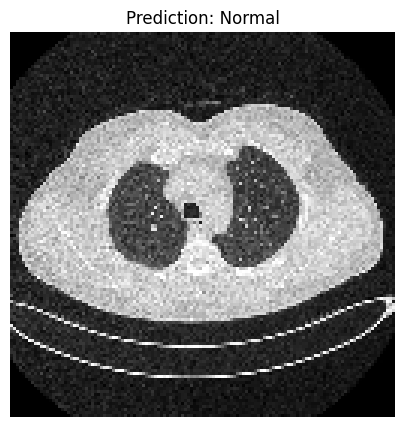

Prediction probabilities: [[2.5413625e-03 9.7937195e-04 9.9647933e-01]]


In [19]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["Benign", "Malignant", "Normal"]

# choose another image
index = 25

plt.figure(figsize=(5,5))
plt.imshow(X_test[index].reshape(128,128), cmap="gray")

prediction = model.predict(X_test[index].reshape(1,128,128,1))
predicted_class = classes[np.argmax(prediction)]

plt.title("Prediction: " + predicted_class)
plt.axis("off")
plt.savefig("prediction_normal.png")
plt.show()

print("Prediction probabilities:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


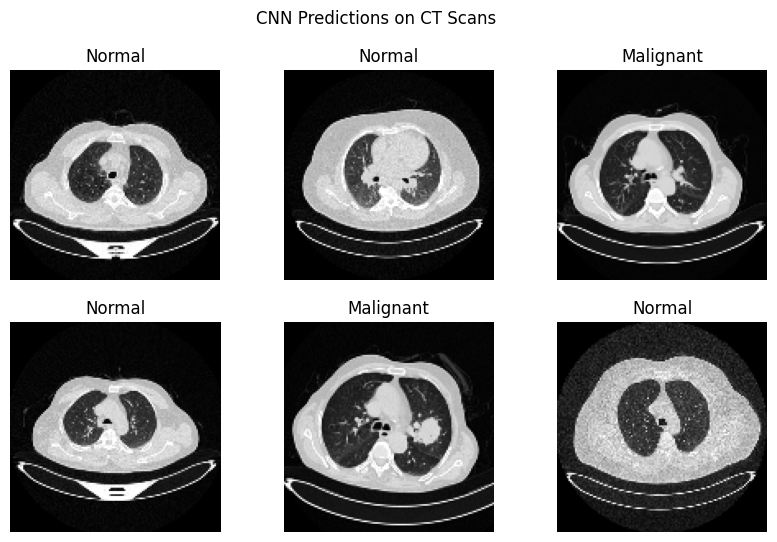

In [20]:
import matplotlib.pyplot as plt
import numpy as np

classes = ["Benign", "Malignant", "Normal"]

plt.figure(figsize=(10,6))

for i in range(6):
    
    plt.subplot(2,3,i+1)
    
    plt.imshow(X_test[i].reshape(128,128), cmap="gray")
    
    prediction = model.predict(X_test[i].reshape(1,128,128,1))
    predicted_class = classes[np.argmax(prediction)]
    
    plt.title(predicted_class)
    plt.axis("off")

plt.suptitle("CNN Predictions on CT Scans")
plt.show()